### Imports

In [30]:
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    print("Running in Google Colab")

    repo_dir = "/content/keyboard_sound"  # fixed absolute path

    if not os.path.exists(repo_dir):
        !git clone https://github.com/ayushma18/keyboard_sound {repo_dir}

    %cd {repo_dir}

    !pip install -r requirements_colab.txt

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import librosa
import os
import random
import seaborn as sns
import pandas as pd
import pickle
import torchaudio
import soundfile as sf

from torchaudio.transforms import TimeMasking, FrequencyMasking
from torchinfo import summary
from tqdm import tqdm
from torchvision import datasets, transforms
from collections import defaultdict
from torchvision.transforms import Compose, ToTensor
from torch.utils.data import DataLoader, Dataset
from scipy.io import wavfile
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

pd.set_option('future.no_silent_downcasting', True)

/tmp/ipykernel_30345/1340087408.py:28: Pandas4Warning: 'future.no_silent_downcasting' is deprecated, please refrain from using it.
  pd.set_option('future.no_silent_downcasting', True)


In [ ]:
import sys, os
if '.' not in sys.path:
    sys.path.insert(0, '.')

from cnn_shared import (
    NoiseLibrary, AggressiveMultiVariationAugmentation, TimeShifting,
    AudioDataset, TrainingDataset, ConvBlock, CNN, init_weights, get_device,
    calculate_rms, add_noise_snr, add_white_noise_snr, add_gaussian_noise_snr, reduce_volume_db,
)
print("✅ Shared classes imported from cnn_shared.py")

In [32]:
data_path= "Data/combined/AULA-NUM"  # Contains 0-9 and a-z (36 classes)
unseen_data_path = "Data/combined/test-num"  # Unseen environment (different person/setup)
noise_path="model/Noises"
best_model_path = f"model/CNN-Best-{data_path.split('/')[-1]}.pkl"
model_path = f"model/CNN-Final-{data_path.split('/')[-1]}.pkl"

### 📌 Dataset Selection

Available datasets in `Data/segmented/`:
- **`alpha-large`** - 26 classes (a-z only)
- **`alphanum-400`** - 36 classes (0-9 and a-z) ✅ **Currently selected**
- **`alphanum-hard-100`** - 36 classes with harder conditions
- **`alphanum-soft-100`** - 36 classes with softer conditions
- **`num-large`** - 10 classes (0-9 only)

Change `data_path` in the cell below to switch datasets.

### Noise Library Loader & Analyzer

In [ ]:
# NoiseLibrary class imported from cnn_shared

# Initialize global noise library
print("Initializing Noise Library...")
noise_library = NoiseLibrary()
print("✅ Noise Library Ready!\n")

Initializing Noise Library...
Loading noise library...

✅ Loaded 36 noise samples:
  - city: 3 samples | Avg length: 584.13s | Avg RMS: 0.0678
  - classroom: 13 samples | Avg length: 231.23s | Avg RMS: 0.0599
  - office: 3 samples | Avg length: 285.93s | Avg RMS: 0.0172
  - common: 17 samples | Avg length: 156.71s | Avg RMS: 0.0356
✅ Noise Library Ready!



### SNR-Based Noise Addition Functions

In [ ]:
# calculate_rms, add_noise_snr, add_white_noise_snr, add_gaussian_noise_snr,
# and reduce_volume_db are all imported from cnn_shared

### Hybrid Noise Augmentation Pipeline

In [ ]:
# AggressiveMultiVariationAugmentation class imported from cnn_shared

# Initialize AGGRESSIVE multi-variation augmentation
print("\n" + "="*70)
print("🔥 INITIALIZING AGGRESSIVE MULTI-VARIATION AUGMENTATION FOR TRAINING")
print("="*70)
aggressive_aug = AggressiveMultiVariationAugmentation(
    noise_library=noise_library,
    snr_range=(5, 30),              # Min 5dB prevents signal cancellation → NaN
    volume_reduction_prob=0.4,
    volume_reduction_range=(2, 15),
    multi_aug_prob=0.3
)
print("="*70 + "\n")


🔥 INITIALIZING AGGRESSIVE MULTI-VARIATION AUGMENTATION FOR TRAINING
🔥 AGGRESSIVE Multi-Variation Augmentation Configuration:
  ├─ Strategies: 9 different noise types
  ├─ SNR range: 5-30 dB
  ├─ Volume reduction: 40% chance
  ├─ Volume reduction range: 2-15 dB
  ├─ Multi-augmentation: 30% chance
  └─ Clean samples: 0% (ALWAYS AUGMENTED!)



### Loading data

In [ ]:
# AudioDataset class imported from cnn_shared

In [37]:
# Configure audio loading backend
# In newer torchaudio versions, soundfile is used automatically if installed
# The set_audio_backend API was removed - backends are auto-selected
print("ℹ️  torchaudio will auto-select backend (soundfile is installed)")

sample_rate = 44100
to_mel_spectrogram = torchaudio.transforms.MelSpectrogram(sample_rate, n_mels=64, hop_length=300, n_fft=2048, win_length=1024)
mel_spectrogram_to_numpy = lambda spectrogram: spectrogram.clamp(min=1e-9).log2()[0,:,:].numpy()
transforms = Compose([to_mel_spectrogram, mel_spectrogram_to_numpy, ToTensor()])
dataset = AudioDataset(data_path, None)  # Store raw audio; transforms applied by TrainingDataset
print("number of classes:", dataset.num_classes())


ℹ️  torchaudio will auto-select backend (soundfile is installed)
number of classes: 10


In [38]:
# 🔍 Diagnostic: Check if dataset path exists and has files
import os

print("📂 Checking dataset path...")
print(f"   data_path = '{data_path}'")
print(f"   Path exists: {os.path.exists(data_path)}")

if os.path.exists(data_path):
    # List subdirectories (should be letter folders)
    subdirs = [d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))]
    print(f"   Found {len(subdirs)} subdirectories: {sorted(subdirs)[:10]}...")
    
    # Count total audio files
    total_files = 0
    for subdir in subdirs:
        subdir_path = os.path.join(data_path, subdir)
        files = [f for f in os.listdir(subdir_path) if f.endswith('.wav')]
        total_files += len(files)
    
    print(f"   Total .wav files: {total_files}")
    
    if total_files == 0:
        print("   ⚠️  No .wav files found! Check if audio files are present.")
else:
    print(f"   ❌ Path does NOT exist!")
    print(f"   Current working directory: {os.getcwd()}")
    print(f"   \n💡 Suggestion: The correct path should be 'Data/segmented/alpha-large'")
    print(f"   Run cell 4 again to set the correct path, then re-run this cell.")

📂 Checking dataset path...
   data_path = 'Data/combined/AULA-NUM'
   Path exists: True
   Found 10 subdirectories: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']...
   Total .wav files: 4000


In [39]:
targets = [data[1] for data in dataset]

train_indices, tmp_indices = train_test_split(
    range(len(dataset)),
    test_size=0.3,
    stratify=targets
)

val_indices, test_indices = train_test_split(
    tmp_indices,
    test_size=0.33,
    stratify=[targets[i] for i in tmp_indices]
)

init_train_set = torch.utils.data.Subset(dataset, train_indices)
init_val_set = torch.utils.data.Subset(dataset, val_indices)
init_test_set = torch.utils.data.Subset(dataset, test_indices)

print("Sample rate:", sample_rate)
print(f"Train set size: {len(init_train_set)}, Validation set size: {len(init_val_set)}, Test set size: {len(init_test_set)}")

Sample rate: 44100
Train set size: 2800, Validation set size: 804, Test set size: 396


### Data Augmentation - AGGRESSIVE Multi-Variation Training


In [ ]:
# TrainingDataset class imported from cnn_shared

In [ ]:
# TimeShifting class imported from cnn_shared

In [42]:
# 🔥 AGGRESSIVE Multi-Variation Augmentation Pipeline for Hard Training
# Combines: Aggressive Multi-Noise + Time Shifting + HEAVY Spectrogram Masking
# Goal: Force model to learn from MAXIMUM variation (small to large noise)
aug_transforms = Compose([
    aggressive_aug,                  # Apply aggressive multi-variation noise FIRST
    TimeShifting(shift_ratio=0.5),   # Time shifting (50%)
    to_mel_spectrogram,              # Convert to mel spectrogram
    mel_spectrogram_to_numpy,        # Convert to numpy
    ToTensor(),                      # Convert to tensor
    # HEAVY spectrogram masking for additional robustness

    # FrequencyMasking(4),             # Third pass (lighter)
    # TimeMasking(6),                  # Third pass (lighter)
])

# Training datasets with augmentation and without
train_set = TrainingDataset(init_train_set, aug_transforms)
train_set_no_aug = TrainingDataset(init_train_set, transforms)
val_set = TrainingDataset(init_val_set, transforms)
test_set = TrainingDataset(init_test_set, transforms)

print(f"\n" + "="*70)
print("✅ AGGRESSIVE TRAINING DATASETS CREATED")
print("="*70)
print(f"  ├─ Train (AGGRESSIVE augmentation): {len(train_set)} samples")
print(f"  │   └─ Each sample gets:")
print(f"  │       • One of 9 noise strategies (SNR 0-30dB)")
print(f"  │       • 30% chance of double augmentation")
print(f"  │       • 40% chance of volume reduction")
print(f"  │       • Time shifting (50% range)")
print(f"  │       • 6 layers of spectrogram masking")
print(f"  │")
print(f"  ├─ Train (no augmentation): {len(train_set_no_aug)} samples")
print(f"  ├─ Validation (no augmentation): {len(val_set)} samples")
print(f"  └─ Test (no augmentation): {len(test_set)} samples")
print("="*70)
print("\n💪 Model will be trained on MAXIMUM variation for robustness!")
print("="*70 + "\n")



✅ AGGRESSIVE TRAINING DATASETS CREATED
  ├─ Train (AGGRESSIVE augmentation): 2800 samples
  │   └─ Each sample gets:
  │       • One of 9 noise strategies (SNR 0-30dB)
  │       • 30% chance of double augmentation
  │       • 40% chance of volume reduction
  │       • Time shifting (50% range)
  │       • 6 layers of spectrogram masking
  │
  ├─ Train (no augmentation): 2800 samples
  ├─ Validation (no augmentation): 804 samples
  └─ Test (no augmentation): 396 samples

💪 Model will be trained on MAXIMUM variation for robustness!



### 🔍 Test Noise Augmentation (Optional - Run to Verify)

In [43]:
# Load a sample waveform for testing noise augmentation
from IPython.display import Audio, display

# Create temp directory if it doesn't exist
temp_audio_dir = '/tmp/noise_samples'
os.makedirs(temp_audio_dir, exist_ok=True)

# Get a sample from the training set (before augmentation)
test_waveform, test_label = init_train_set[0]
print(f"✅ Loaded test sample:")
print(f"   Label index: {test_label.item()}")
print(f"   Waveform shape: {test_waveform.shape}")
print(f"   Sample rate: {sample_rate} Hz")
print(f"   Duration: {test_waveform.shape[1]/sample_rate:.3f} seconds")
print(f"   RMS: {calculate_rms(test_waveform).item():.6f}")

# Save and play original clean audio
clean_audio = test_waveform.numpy()[0] if test_waveform.ndim > 1 else test_waveform.numpy()
clean_path = os.path.join(temp_audio_dir, 'clean_original.wav')
sf.write(clean_path, clean_audio, sample_rate)

print("\n1️⃣  ORIGINAL CLEAN AUDIO")
display(Audio(clean_path, rate=sample_rate))

✅ Loaded test sample:
   Label index: 0
   Waveform shape: torch.Size([1, 18963])
   Sample rate: 44100 Hz
   Duration: 0.430 seconds
   RMS: 0.001358

1️⃣  ORIGINAL CLEAN AUDIO


In [44]:
# 5. Save and play VOLUME REDUCED (simulating far microphone)
volume_reduced_6db = reduce_volume_db(test_waveform, db_reduction=6)
volume_reduced_12db = reduce_volume_db(test_waveform, db_reduction=12)

vol_6db_audio = volume_reduced_6db.numpy()[0] if volume_reduced_6db.ndim > 1 else volume_reduced_6db.numpy()
vol_12db_audio = volume_reduced_12db.numpy()[0] if volume_reduced_12db.ndim > 1 else volume_reduced_12db.numpy()

vol_6db_path = os.path.join(temp_audio_dir, 'volume_reduced_6db.wav')
vol_12db_path = os.path.join(temp_audio_dir, 'volume_reduced_12db.wav')
sf.write(vol_6db_path, vol_6db_audio, sample_rate)
sf.write(vol_12db_path, vol_12db_audio, sample_rate)

print("\n5️⃣  VOLUME REDUCED (Distant Microphone)")
print(f"   🔉 -6 dB reduction - RMS: {calculate_rms(volume_reduced_6db).item():.6f}")
display(Audio(vol_6db_path, rate=sample_rate))
print(f"   🔉 -12 dB reduction - RMS: {calculate_rms(volume_reduced_12db).item():.6f}")
display(Audio(vol_12db_path, rate=sample_rate))


5️⃣  VOLUME REDUCED (Distant Microphone)
   🔉 -6 dB reduction - RMS: 0.000681


   🔉 -12 dB reduction - RMS: 0.000341


In [45]:
# 4. Save and play GAUSSIAN NOISE
gaussian_noise_10db = add_gaussian_noise_snr(test_waveform, target_snr_db=10)
gaussian_noise_5db = add_gaussian_noise_snr(test_waveform, target_snr_db=5)

gaussian_10db_audio = gaussian_noise_10db.numpy()[0] if gaussian_noise_10db.ndim > 1 else gaussian_noise_10db.numpy()
gaussian_5db_audio = gaussian_noise_5db.numpy()[0] if gaussian_noise_5db.ndim > 1 else gaussian_noise_5db.numpy()

gaussian_10db_path = os.path.join(temp_audio_dir, 'gaussian_noise_10db.wav')
gaussian_5db_path = os.path.join(temp_audio_dir, 'gaussian_noise_5db.wav')
sf.write(gaussian_10db_path, gaussian_10db_audio, sample_rate)
sf.write(gaussian_5db_path, gaussian_5db_audio, sample_rate)

print("\n4️⃣  GAUSSIAN NOISE")
print(f"   🔊 Light noise (10 dB SNR) - RMS: {calculate_rms(gaussian_noise_10db).item():.6f}")
display(Audio(gaussian_10db_path, rate=sample_rate))
print(f"   🔊 Heavy noise (5 dB SNR) - RMS: {calculate_rms(gaussian_noise_5db).item():.6f}")
display(Audio(gaussian_5db_path, rate=sample_rate))


4️⃣  GAUSSIAN NOISE
   🔊 Light noise (10 dB SNR) - RMS: 0.001422


   🔊 Heavy noise (5 dB SNR) - RMS: 0.001563


In [46]:
# 3. Save and play WHITE NOISE
white_noise_10db = add_white_noise_snr(test_waveform, target_snr_db=10)
white_noise_5db = add_white_noise_snr(test_waveform, target_snr_db=5)

white_10db_audio = white_noise_10db.numpy()[0] if white_noise_10db.ndim > 1 else white_noise_10db.numpy()
white_5db_audio = white_noise_5db.numpy()[0] if white_noise_5db.ndim > 1 else white_noise_5db.numpy()

white_10db_path = os.path.join(temp_audio_dir, 'white_noise_10db.wav')
white_5db_path = os.path.join(temp_audio_dir, 'white_noise_5db.wav')
sf.write(white_10db_path, white_10db_audio, sample_rate)
sf.write(white_5db_path, white_5db_audio, sample_rate)

print("\n3️⃣  WHITE NOISE (Uniform Random)")
print(f"   🔊 Light noise (10 dB SNR) - RMS: {calculate_rms(white_noise_10db).item():.6f}")
display(Audio(white_10db_path, rate=sample_rate))
print(f"   🔊 Heavy noise (5 dB SNR) - RMS: {calculate_rms(white_noise_5db).item():.6f}")
display(Audio(white_5db_path, rate=sample_rate))


3️⃣  WHITE NOISE (Uniform Random)
   🔊 Light noise (10 dB SNR) - RMS: 0.001429


   🔊 Heavy noise (5 dB SNR) - RMS: 0.001561


In [47]:
# 2. Save and play REAL AMBIENT NOISE (Office/City/Classroom)
# Get noise segments
noise_segment_10db = noise_library.get_noise_segment(test_waveform.shape[1])
noise_segment_5db = noise_library.get_noise_segment(test_waveform.shape[1])

# Check if noise library has samples
if noise_segment_10db is None or noise_segment_5db is None:
    print("\n2️⃣  REAL AMBIENT NOISE (Office/City/Classroom)")
    print("   ⚠️  No noise samples found in the noise library.")
    print(f"   Noise path: {noise_path}")
    print("   Make sure noise files exist in: model/Noises/{city,classroom,office,Common Noises}/")
    print("   Skipping real noise examples...")
else:
    real_noise_10db = add_noise_snr(test_waveform, noise_segment_10db, target_snr_db=10)
    real_noise_5db = add_noise_snr(test_waveform, noise_segment_5db, target_snr_db=5)

    # Convert to numpy
    real_10db_audio = real_noise_10db.numpy()[0] if real_noise_10db.ndim > 1 else real_noise_10db.numpy()
    real_5db_audio = real_noise_5db.numpy()[0] if real_noise_5db.ndim > 1 else real_noise_5db.numpy()

    # Save
    real_10db_path = os.path.join(temp_audio_dir, 'real_ambient_10db.wav')
    real_5db_path = os.path.join(temp_audio_dir, 'real_ambient_5db.wav')
    sf.write(real_10db_path, real_10db_audio, sample_rate)
    sf.write(real_5db_path, real_5db_audio, sample_rate)

    print("\n2️⃣  REAL AMBIENT NOISE (Office/City/Classroom)")
    print(f"   🔊 Light noise (10 dB SNR) - RMS: {calculate_rms(real_noise_10db).item():.6f}")
    display(Audio(real_10db_path, rate=sample_rate))
    print(f"   🔊 Heavy noise (5 dB SNR) - RMS: {calculate_rms(real_noise_5db).item():.6f}")
    display(Audio(real_5db_path, rate=sample_rate))


2️⃣  REAL AMBIENT NOISE (Office/City/Classroom)
   🔊 Light noise (10 dB SNR) - RMS: 0.001424


   🔊 Heavy noise (5 dB SNR) - RMS: 0.001565


### Visualization

torch.Size([64, 64])


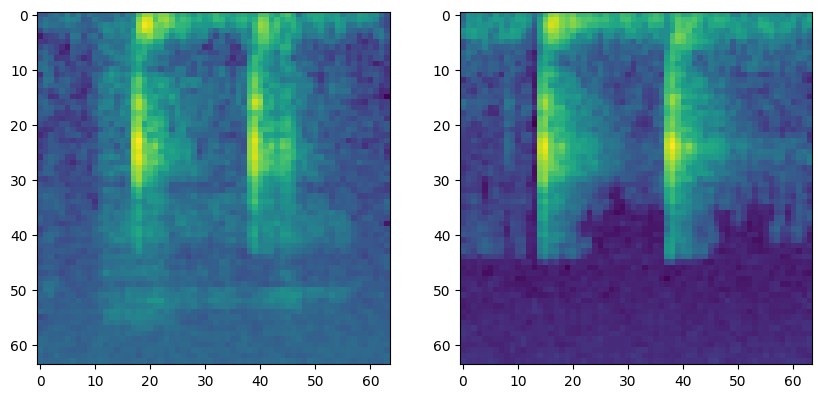

In [48]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(train_set[3][0][0], cmap='viridis')
ax2.imshow(val_set[0][0][0], cmap='viridis')
print(train_set[0][0][0].shape)
ax1.grid(False)
ax2.grid(False)
plt.show()

### CNN Model

In [ ]:
# ConvBlock class imported from cnn_shared

In [ ]:
# CNN class imported from cnn_shared

In [51]:
model = CNN(num_classes=dataset.num_classes())

In [ ]:
# init_weights function imported from cnn_shared

In [ ]:
# get_device function imported from cnn_shared

device = get_device()

model.apply(init_weights)
model.to(device)

print("Number of parameters: {:,}".format(sum(p.numel() for p in model.parameters())))
print(f"Device: {device}")

summary(model, input_size=(1, 1, 64, 64))

Number of parameters: 4,853,578
Device: cuda


Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [1, 10]                   --
├─ConvBlock: 1-1                         [1, 64, 64, 64]           --
│    └─Sequential: 2-1                   [1, 64, 64, 64]           --
│    │    └─Conv2d: 3-1                  [1, 64, 64, 64]           640
│    │    └─BatchNorm2d: 3-2             [1, 64, 64, 64]           128
│    │    └─ReLU: 3-3                    [1, 64, 64, 64]           --
│    │    └─Conv2d: 3-4                  [1, 64, 64, 64]           36,928
│    │    └─BatchNorm2d: 3-5             [1, 64, 64, 64]           128
│    │    └─ReLU: 3-6                    [1, 64, 64, 64]           --
├─MaxPool2d: 1-2                         [1, 64, 32, 32]           --
├─Dropout2d: 1-3                         [1, 64, 32, 32]           --
├─ConvBlock: 1-4                         [1, 128, 32, 32]          --
│    └─Sequential: 2-2                   [1, 128, 32, 32]          --
│    │  

### Training setup

In [54]:

train_dataloader = torch.utils.data.DataLoader(
    train_set,
    batch_size=32,
    shuffle=True
)

val_dataloader = torch.utils.data.DataLoader(
    val_set,
    batch_size=32,
    shuffle=False
)

test_dataloader = torch.utils.data.DataLoader(
    test_set,
    batch_size=32,
    shuffle=False
)

# Unseen environment — evaluated every epoch to track cross-environment generalisation
unseen_dataset = AudioDataset(unseen_data_path, None)
unseen_set = TrainingDataset(unseen_dataset, transforms)
unseen_dataloader = torch.utils.data.DataLoader(
    unseen_set,
    batch_size=32,
    shuffle=False
)

print(f"✅ Dataloaders ready")
print(f"   Train   : {len(train_set):>5} samples  ({data_path.split('/')[-1]})")
print(f"   Val     : {len(val_set):>5} samples  ({data_path.split('/')[-1]})")
print(f"   Test    : {len(test_set):>5} samples  ({data_path.split('/')[-1]})")
print(f"   Unseen  : {len(unseen_set):>5} samples  ({unseen_data_path.split('/')[-1]})")


✅ Dataloaders ready
   Train   :  2800 samples  (AULA-NUM)
   Val     :   804 samples  (AULA-NUM)
   Test    :   396 samples  (AULA-NUM)
   Unseen  :   410 samples  (test-num)


In [55]:
cost = nn.CrossEntropyLoss()

learning_rate = 1e-3
weight_decay = 1e-4
max_epochs = 1200  # Maximum epochs (safety limit)

# Early Stopping Parameters
early_stopping_patience = 50  # Stop if no improvement for 50 epochs
early_stopping_min_delta = 0.001  # Minimum change to qualify as improvement

optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

### Training

In [56]:

def plot_results(train_losses, train_accuracies, val_losses, val_accuracies, unseen_accuracies=None):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.title("Loss")
    plt.plot(train_losses)
    plt.plot(val_losses)
    plt.legend(["Training loss", "Validation loss"], loc="best")

    plt.subplot(1, 2, 2)
    plt.title("Accuracy")
    plt.plot(train_accuracies)
    plt.plot(val_accuracies)
    legend_labels = ["Training accuracy", "Validation accuracy"]
    if unseen_accuracies is not None:
        plt.plot(unseen_accuracies, linestyle='--', color='orange')
        legend_labels.append("Unseen env accuracy")
    plt.legend(legend_labels, loc="best")
    plt.show()


In [57]:
def save_model(model, path):
    torch.save(model.state_dict(), path)

class EarlyStopping:
    """Early stopping to stop training when validation loss doesn't improve"""
    def __init__(self, patience=50, min_delta=0.001, mode='min'):
        """
        Args:
            patience: Number of epochs to wait after last improvement
            min_delta: Minimum change in monitored metric to qualify as improvement
            mode: 'min' for loss (lower is better), 'max' for accuracy (higher is better)
        """
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.improved = False
        
    def __call__(self, current_score):
        """Check if training should stop"""
        self.improved = False
        
        if self.best_score is None:
            self.best_score = current_score
            self.improved = True
        elif self.mode == 'min':
            if current_score < self.best_score - self.min_delta:
                self.best_score = current_score
                self.counter = 0
                self.improved = True
            else:
                self.counter += 1
        else:  # mode == 'max'
            if current_score > self.best_score + self.min_delta:
                self.best_score = current_score
                self.counter = 0
                self.improved = True
            else:
                self.counter += 1
        
        if self.counter >= self.patience:
            self.early_stop = True
            
        return self.early_stop

🚀 Starting training with early stopping:
   • Max epochs: 1200
   • Early stopping patience: 50 epochs
   • Min delta: 0.001
   • Monitoring: Validation Loss
   • Unseen env: test-num

Epoch [1/1200], Train Loss: 2.6500, Train Acc: 0.1004, Val Loss: 2.2967, Val Acc: 0.1169, Unseen Acc: 0.0976
  ✓ Best model saved with validation accuracy: 0.1169
Epoch [2/1200], Train Loss: 2.3226, Train Acc: 0.1111, Val Loss: 2.2965, Val Acc: 0.1007, Unseen Acc: 0.1073
Epoch [3/1200], Train Loss: 2.3071, Train Acc: 0.1100, Val Loss: 2.2962, Val Acc: 0.1468, Unseen Acc: 0.1317
  ✓ Best model saved with validation accuracy: 0.1468
Epoch [4/1200], Train Loss: 2.3091, Train Acc: 0.1089, Val Loss: 2.3023, Val Acc: 0.1107, Unseen Acc: 0.1049
Epoch [5/1200], Train Loss: 2.3062, Train Acc: 0.0911, Val Loss: 2.2972, Val Acc: 0.1244, Unseen Acc: 0.1293
Epoch [6/1200], Train Loss: 2.3047, Train Acc: 0.1021, Val Loss: 2.3018, Val Acc: 0.0858, Unseen Acc: 0.1024
Epoch [7/1200], Train Loss: 2.3038, Train Acc: 0.0979

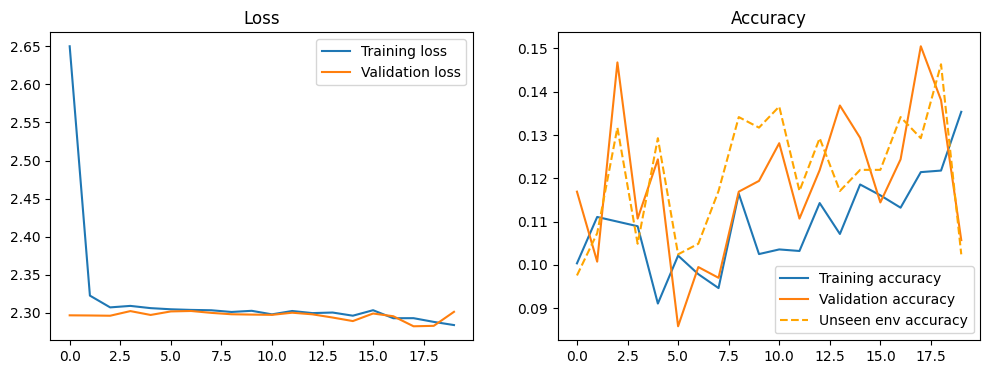

Epoch [21/1200], Train Loss: 2.2797, Train Acc: 0.1264, Val Loss: 2.2598, Val Acc: 0.1903, Unseen Acc: 0.1293
  ✓ Best model saved with validation accuracy: 0.1903
Epoch [22/1200], Train Loss: 2.2681, Train Acc: 0.1404, Val Loss: 2.2763, Val Acc: 0.1331, Unseen Acc: 0.1293
Epoch [23/1200], Train Loss: 2.2536, Train Acc: 0.1439, Val Loss: 2.1877, Val Acc: 0.2065, Unseen Acc: 0.1659
  ✓ Best model saved with validation accuracy: 0.2065
Epoch [24/1200], Train Loss: 2.2252, Train Acc: 0.1479, Val Loss: 2.2272, Val Acc: 0.1704, Unseen Acc: 0.1341
Epoch [25/1200], Train Loss: 2.1798, Train Acc: 0.1746, Val Loss: 2.0754, Val Acc: 0.1990, Unseen Acc: 0.1610
Epoch [26/1200], Train Loss: 2.1596, Train Acc: 0.1632, Val Loss: 2.1249, Val Acc: 0.2090, Unseen Acc: 0.1439
  ✓ Best model saved with validation accuracy: 0.2090
Epoch [27/1200], Train Loss: 2.1140, Train Acc: 0.1825, Val Loss: 2.1664, Val Acc: 0.1493, Unseen Acc: 0.1220
Epoch [28/1200], Train Loss: 2.0981, Train Acc: 0.1950, Val Loss: 2.

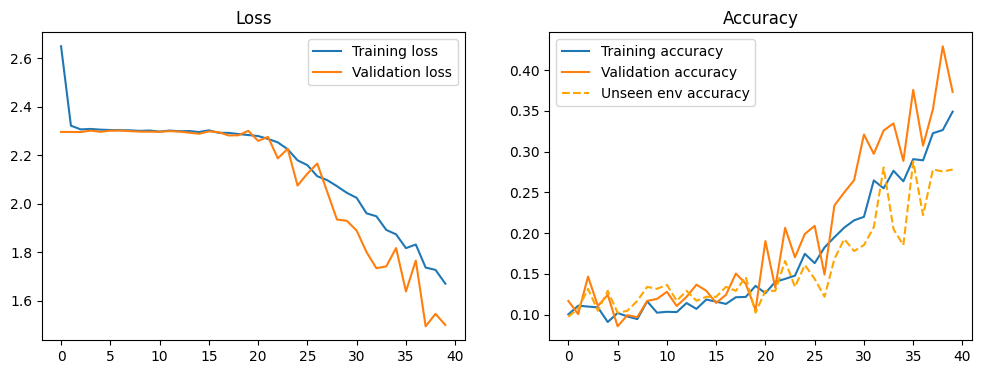

Epoch [41/1200], Train Loss: 1.6336, Train Acc: 0.3557, Val Loss: 1.4394, Val Acc: 0.4590, Unseen Acc: 0.2927
  ✓ Best model saved with validation accuracy: 0.4590
Epoch [42/1200], Train Loss: 1.6082, Train Acc: 0.3739, Val Loss: 1.4087, Val Acc: 0.4192, Unseen Acc: 0.3024
Epoch [43/1200], Train Loss: 1.5410, Train Acc: 0.3854, Val Loss: 1.2665, Val Acc: 0.5323, Unseen Acc: 0.3268
  ✓ Best model saved with validation accuracy: 0.5323
Epoch [44/1200], Train Loss: 1.5200, Train Acc: 0.4100, Val Loss: 1.3335, Val Acc: 0.5087, Unseen Acc: 0.2927
Epoch [45/1200], Train Loss: 1.4484, Train Acc: 0.4179, Val Loss: 1.3224, Val Acc: 0.4415, Unseen Acc: 0.2634
Epoch [46/1200], Train Loss: 1.4299, Train Acc: 0.4293, Val Loss: 1.2094, Val Acc: 0.5522, Unseen Acc: 0.3171
  ✓ Best model saved with validation accuracy: 0.5522
Epoch [47/1200], Train Loss: 1.3421, Train Acc: 0.4614, Val Loss: 1.0556, Val Acc: 0.5771, Unseen Acc: 0.3854
  ✓ Best model saved with validation accuracy: 0.5771
Epoch [48/1200

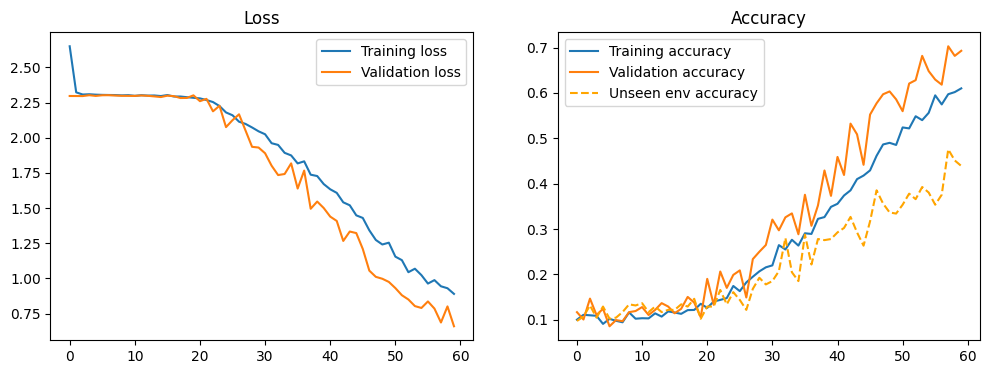

Epoch [61/1200], Train Loss: 0.8415, Train Acc: 0.6425, Val Loss: 0.6324, Val Acc: 0.7500, Unseen Acc: 0.4732
  ✓ Best model saved with validation accuracy: 0.7500
Epoch [62/1200], Train Loss: 0.7860, Train Acc: 0.6696, Val Loss: 0.5871, Val Acc: 0.7600, Unseen Acc: 0.4829
  ✓ Best model saved with validation accuracy: 0.7600
Epoch [63/1200], Train Loss: 0.7697, Train Acc: 0.6957, Val Loss: 0.5274, Val Acc: 0.7886, Unseen Acc: 0.4976
  ✓ Best model saved with validation accuracy: 0.7886
Epoch [64/1200], Train Loss: 0.7169, Train Acc: 0.7132, Val Loss: 0.4852, Val Acc: 0.8022, Unseen Acc: 0.4951
  ✓ Best model saved with validation accuracy: 0.8022
Epoch [65/1200], Train Loss: 0.6684, Train Acc: 0.7361, Val Loss: 0.4913, Val Acc: 0.8109, Unseen Acc: 0.5098
  ✓ Best model saved with validation accuracy: 0.8109
Epoch [66/1200], Train Loss: 0.6611, Train Acc: 0.7582, Val Loss: 0.3987, Val Acc: 0.8308, Unseen Acc: 0.5341
  ✓ Best model saved with validation accuracy: 0.8308
Epoch [67/1200],

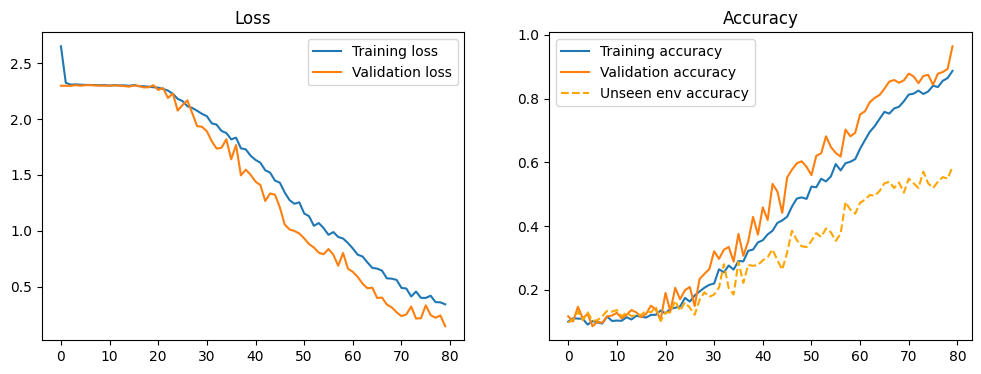

  ✓ Best model saved with validation accuracy: 0.9639
Epoch [81/1200], Train Loss: 0.3487, Train Acc: 0.8932, Val Loss: 0.1751, Val Acc: 0.9192, Unseen Acc: 0.5902
Epoch [82/1200], Train Loss: 0.3104, Train Acc: 0.8989, Val Loss: 0.0838, Val Acc: 0.9751, Unseen Acc: 0.5610
  ✓ Best model saved with validation accuracy: 0.9751
Epoch [83/1200], Train Loss: 0.2785, Train Acc: 0.9114, Val Loss: 0.0987, Val Acc: 0.9577, Unseen Acc: 0.5951
Epoch [84/1200], Train Loss: 0.2889, Train Acc: 0.9157, Val Loss: 0.1027, Val Acc: 0.9652, Unseen Acc: 0.5951
Epoch [85/1200], Train Loss: 0.2607, Train Acc: 0.9189, Val Loss: 0.0669, Val Acc: 0.9776, Unseen Acc: 0.5732
  ✓ Best model saved with validation accuracy: 0.9776
Epoch [86/1200], Train Loss: 0.2583, Train Acc: 0.9243, Val Loss: 0.0591, Val Acc: 0.9764, Unseen Acc: 0.6317
Epoch [87/1200], Train Loss: 0.2704, Train Acc: 0.9264, Val Loss: 0.0582, Val Acc: 0.9801, Unseen Acc: 0.6000
  ✓ Best model saved with validation accuracy: 0.9801
Epoch [88/1200

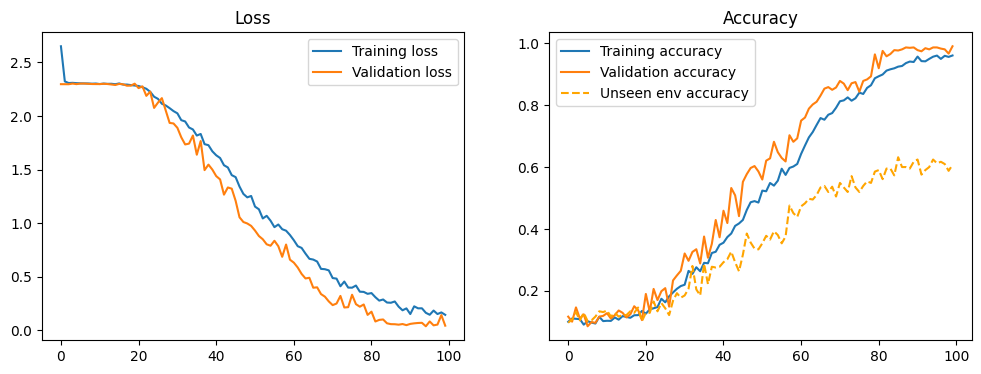

  ✓ Best model saved with validation accuracy: 0.9900
Epoch [101/1200], Train Loss: 0.1555, Train Acc: 0.9589, Val Loss: 0.0739, Val Acc: 0.9776, Unseen Acc: 0.6171
Epoch [102/1200], Train Loss: 0.2230, Train Acc: 0.9468, Val Loss: 0.0583, Val Acc: 0.9813, Unseen Acc: 0.5780
Epoch [103/1200], Train Loss: 0.2076, Train Acc: 0.9432, Val Loss: 0.1169, Val Acc: 0.9764, Unseen Acc: 0.5854
Epoch [104/1200], Train Loss: 0.1583, Train Acc: 0.9546, Val Loss: 0.0564, Val Acc: 0.9826, Unseen Acc: 0.6049
Epoch [105/1200], Train Loss: 0.1122, Train Acc: 0.9689, Val Loss: 0.0596, Val Acc: 0.9851, Unseen Acc: 0.6122
Epoch [106/1200], Train Loss: 0.1461, Train Acc: 0.9650, Val Loss: 0.1438, Val Acc: 0.9751, Unseen Acc: 0.5805
Epoch [107/1200], Train Loss: 0.1202, Train Acc: 0.9646, Val Loss: 0.0493, Val Acc: 0.9863, Unseen Acc: 0.6195
Epoch [108/1200], Train Loss: 0.1138, Train Acc: 0.9675, Val Loss: 0.0656, Val Acc: 0.9826, Unseen Acc: 0.6146
Epoch [109/1200], Train Loss: 0.0818, Train Acc: 0.9771, V

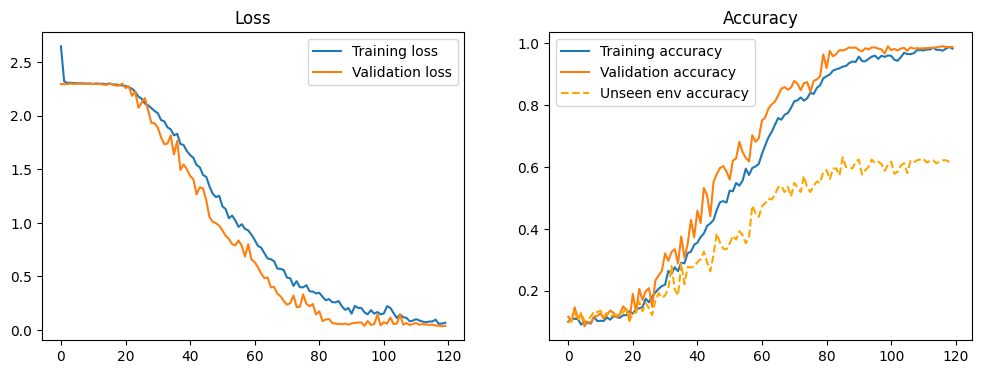

Epoch [121/1200], Train Loss: 0.0637, Train Acc: 0.9861, Val Loss: 0.0420, Val Acc: 0.9863, Unseen Acc: 0.6122
Epoch [122/1200], Train Loss: 0.0721, Train Acc: 0.9854, Val Loss: 0.0376, Val Acc: 0.9888, Unseen Acc: 0.6122
Epoch [123/1200], Train Loss: 0.0551, Train Acc: 0.9868, Val Loss: 0.0319, Val Acc: 0.9925, Unseen Acc: 0.6268
  ✓ Best model saved with validation accuracy: 0.9925
Epoch [124/1200], Train Loss: 0.0666, Train Acc: 0.9800, Val Loss: 0.0423, Val Acc: 0.9876, Unseen Acc: 0.6244
Epoch [125/1200], Train Loss: 0.0391, Train Acc: 0.9886, Val Loss: 0.0297, Val Acc: 0.9888, Unseen Acc: 0.6146
Epoch [126/1200], Train Loss: 0.0567, Train Acc: 0.9839, Val Loss: 0.0262, Val Acc: 0.9913, Unseen Acc: 0.6220
Epoch [127/1200], Train Loss: 0.0456, Train Acc: 0.9879, Val Loss: 0.0276, Val Acc: 0.9888, Unseen Acc: 0.6171
Epoch [128/1200], Train Loss: 0.0496, Train Acc: 0.9879, Val Loss: 0.0295, Val Acc: 0.9900, Unseen Acc: 0.6268
Epoch [129/1200], Train Loss: 0.0532, Train Acc: 0.9850, V

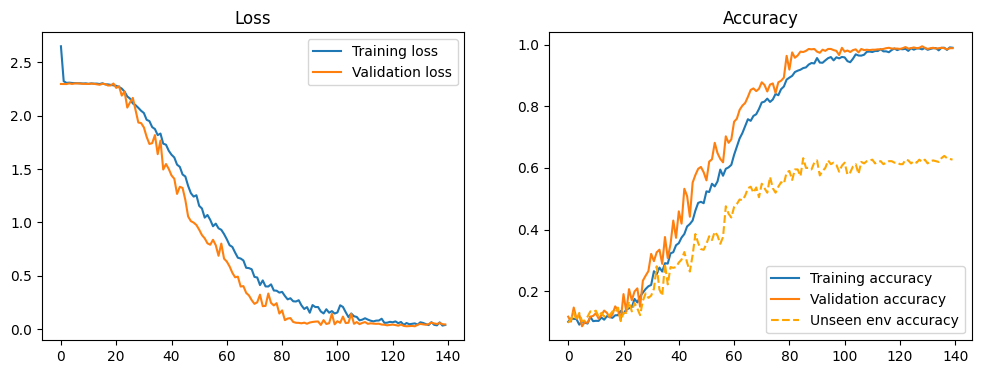

Epoch [141/1200], Train Loss: 0.0300, Train Acc: 0.9921, Val Loss: 0.0402, Val Acc: 0.9913, Unseen Acc: 0.6244
Epoch [142/1200], Train Loss: 0.0415, Train Acc: 0.9875, Val Loss: 0.0355, Val Acc: 0.9913, Unseen Acc: 0.6268
Epoch [143/1200], Train Loss: 0.0377, Train Acc: 0.9918, Val Loss: 0.0359, Val Acc: 0.9900, Unseen Acc: 0.6317
Epoch [144/1200], Train Loss: 0.0338, Train Acc: 0.9929, Val Loss: 0.0410, Val Acc: 0.9913, Unseen Acc: 0.6341
Epoch [145/1200], Train Loss: 0.0416, Train Acc: 0.9893, Val Loss: 0.0454, Val Acc: 0.9900, Unseen Acc: 0.6293
Epoch [146/1200], Train Loss: 0.0425, Train Acc: 0.9879, Val Loss: 0.0427, Val Acc: 0.9900, Unseen Acc: 0.6366
Epoch [147/1200], Train Loss: 0.0334, Train Acc: 0.9914, Val Loss: 0.0360, Val Acc: 0.9925, Unseen Acc: 0.6317
Epoch [148/1200], Train Loss: 0.0294, Train Acc: 0.9932, Val Loss: 0.0366, Val Acc: 0.9913, Unseen Acc: 0.6293
Epoch [149/1200], Train Loss: 0.0450, Train Acc: 0.9879, Val Loss: 0.0346, Val Acc: 0.9913, Unseen Acc: 0.6293
E

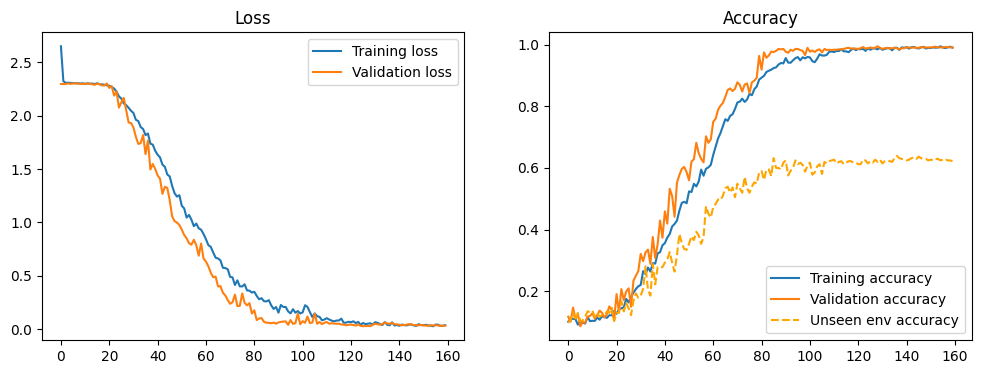

Epoch [161/1200], Train Loss: 0.0506, Train Acc: 0.9882, Val Loss: 0.0330, Val Acc: 0.9913, Unseen Acc: 0.6220
Epoch [162/1200], Train Loss: 0.0299, Train Acc: 0.9939, Val Loss: 0.0319, Val Acc: 0.9925, Unseen Acc: 0.6220
Epoch [163/1200], Train Loss: 0.0327, Train Acc: 0.9914, Val Loss: 0.0316, Val Acc: 0.9913, Unseen Acc: 0.6268
Epoch [164/1200], Train Loss: 0.0363, Train Acc: 0.9921, Val Loss: 0.0313, Val Acc: 0.9913, Unseen Acc: 0.6268
Epoch [165/1200], Train Loss: 0.0282, Train Acc: 0.9925, Val Loss: 0.0295, Val Acc: 0.9913, Unseen Acc: 0.6268
Epoch [166/1200], Train Loss: 0.0385, Train Acc: 0.9904, Val Loss: 0.0334, Val Acc: 0.9925, Unseen Acc: 0.6293
Epoch [167/1200], Train Loss: 0.0239, Train Acc: 0.9939, Val Loss: 0.0323, Val Acc: 0.9913, Unseen Acc: 0.6293
Epoch [168/1200], Train Loss: 0.0219, Train Acc: 0.9943, Val Loss: 0.0285, Val Acc: 0.9913, Unseen Acc: 0.6293
Epoch [169/1200], Train Loss: 0.0377, Train Acc: 0.9925, Val Loss: 0.0320, Val Acc: 0.9913, Unseen Acc: 0.6293
E

In [58]:

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
unseen_accuracies = []
best_val_acc = 0.0

# Initialize early stopping
early_stopping = EarlyStopping(patience=early_stopping_patience, 
                                min_delta=early_stopping_min_delta, 
                                mode='min')  # Monitor validation loss

print(f"🚀 Starting training with early stopping:")
print(f"   • Max epochs: {max_epochs}")
print(f"   • Early stopping patience: {early_stopping_patience} epochs")
print(f"   • Min delta: {early_stopping_min_delta}")
print(f"   • Monitoring: Validation Loss")
print(f"   • Unseen env: {unseen_data_path.split('/')[-1]}\n")

for epoch in range(max_epochs):
    model.train()
    correct = 0
    total = 0
    epoch_loss = 0

    for inputs, labels in train_dataloader:
        inputs = inputs.to(device)
        labels = torch.squeeze(labels).to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = cost(outputs, labels)

        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        epoch_loss += loss.item()

    train_acc = correct / total
    avg_train_loss = epoch_loss / len(train_dataloader)
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)

    model.eval()
    with torch.no_grad():
        # ── Validation ────────────────────────────────────────────────────────
        correct = 0
        total = 0
        val_loss = 0

        for inputs, labels in val_dataloader:
            inputs = inputs.to(device)
            labels = torch.squeeze(labels).to(device)
            outputs = model(inputs)

            loss = cost(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        val_acc = correct / total
        avg_val_loss = val_loss / len(val_dataloader)
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_acc)

        # ── Unseen environment ────────────────────────────────────────────────
        unseen_correct = 0
        unseen_total = 0

        for inputs, labels in unseen_dataloader:
            inputs = inputs.to(device)
            labels = torch.squeeze(labels).to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            unseen_total += labels.size(0)
            unseen_correct += (predicted == labels).sum().item()

        unseen_acc = unseen_correct / unseen_total
        unseen_accuracies.append(unseen_acc)

    scheduler.step(avg_val_loss)

    print(f"Epoch [{epoch + 1}/{max_epochs}], "
          f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f}, "
          f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f}, "
          f"Unseen Acc: {unseen_acc:.4f}")

    if epoch != 0 and (epoch % 20 == 19):
        plot_results(train_losses, train_accuracies, val_losses, val_accuracies, unseen_accuracies)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        save_model(model, best_model_path)
        print(f"  ✓ Best model saved with validation accuracy: {val_acc:.4f}")

    # Early stopping check
    if early_stopping(avg_val_loss):
        print(f"\n🛑 Early stopping triggered after {epoch + 1} epochs")
        print(f"   • No improvement in validation loss for {early_stopping.patience} epochs")
        print(f"   • Best validation loss: {early_stopping.best_score:.4f}")
        print(f"   • Best validation accuracy: {best_val_acc:.4f}")
        break

# Final summary
if not early_stopping.early_stop:
    print(f"\n✅ Training completed - reached maximum epochs ({max_epochs})")
else:
    print(f"\n✅ Training completed - early stopping at epoch {epoch + 1}")

print(f"   • Total epochs trained  : {len(train_losses)}")
print(f"   • Best validation acc   : {best_val_acc:.4f}")
print(f"   • Final validation acc  : {val_accuracies[-1]:.4f}")
print(f"   • Final unseen env acc  : {unseen_accuracies[-1]:.4f}")


In [59]:
save_model(model, model_path)

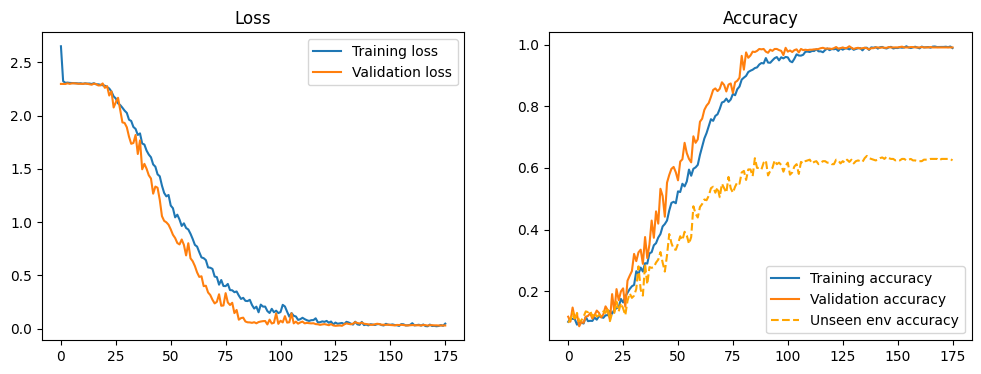


📊 Training Summary:
   • Best validation acc   : 0.9950
   • Last validation acc   : 0.9913
   • Last unseen env acc   : 0.6244
   • Epochs trained        : 176


In [60]:

# Plot final training results
plot_results(train_losses, train_accuracies, val_losses, val_accuracies, unseen_accuracies)

print(f"\n📊 Training Summary:")
print(f"   • Best validation acc   : {max(val_accuracies):.4f}")
print(f"   • Last validation acc   : {val_accuracies[-1]:.4f}")
print(f"   • Last unseen env acc   : {unseen_accuracies[-1]:.4f}")
print(f"   • Epochs trained        : {len(val_accuracies)}")


---

## 🔧 Fine-Tuning

For fine-tuning a trained model on production/deployment data, use:

**[CNN-FineTuning.ipynb](CNN-FineTuning.ipynb)**

This separate notebook allows you to:
- Load a pre-trained model from this notebook
- Fine-tune on small production datasets  
- Freeze early layers for better performance on small data
- Compare original vs fine-tuned model accuracy

---

### Results

In [61]:
model.load_state_dict(torch.load(best_model_path))
model.to(device)
model.eval()

CNN(
  (conv1): ConvBlock(
    (conv): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout2d(p=0.25, inplace=False)
  (conv2): ConvBlock(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=

In [62]:
digits = [str(digit) for digit in range(10)]
alphabet = [chr(ascii_code) for ascii_code in range(ord('A'), ord('Z') + 1)]
all_characters = digits + alphabet
label_dict = {i: all_characters[i] for i in range(len(all_characters))}
print(label_dict)

{0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9', 10: 'A', 11: 'B', 12: 'C', 13: 'D', 14: 'E', 15: 'F', 16: 'G', 17: 'H', 18: 'I', 19: 'J', 20: 'K', 21: 'L', 22: 'M', 23: 'N', 24: 'O', 25: 'P', 26: 'Q', 27: 'R', 28: 'S', 29: 'T', 30: 'U', 31: 'V', 32: 'W', 33: 'X', 34: 'Y', 35: 'Z'}


In [63]:
def predict(data_loader):
    original_labels = []
    predicted_labels = []
    correct = 0
    total = 0

    model.eval()

    for inputs, labels in data_loader:
        inputs = inputs.to(device)
        labels = torch.squeeze(labels).to(device)
        outputs = model(inputs)

        _, predicted = torch.max(outputs.data, 1)

        original_labels.extend(labels.cpu().numpy())
        predicted_labels.extend(predicted.cpu().numpy())

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    prediction_df = pd.DataFrame({
        "predicted_labels": [label_dict[pred] for pred in predicted_labels],
        "true_labels": [label_dict[label] for label in original_labels]
    })

    print(f"Test Accuracy: {correct/total}")
    pd.set_option('display.max_rows', None)
    pd.set_option("display.max_columns", None)
    display(prediction_df.T)

    print(metrics.accuracy_score(original_labels, predicted_labels))
    print(metrics.classification_report(original_labels, predicted_labels))

    return confusion_matrix(original_labels, predicted_labels)

### Test accuracy

In [64]:
cm = predict(test_dataloader)

Test Accuracy: 0.98989898989899


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395
predicted_labels,0,0,1,2,2,4,5,0,7,4,8,7,4,7,9,9,5,4,7,7,6,3,5,6,8,5,7,8,0,7,1,8,0,8,0,9,2,5,4,3,7,6,5,9,0,5,5,2,1,4,9,0,1,7,9,5,6,4,0,2,0,3,4,8,7,4,6,4,6,3,1,9,4,9,6,8,1,1,4,8,2,7,5,3,2,0,6,1,3,2,8,8,0,0,5,7,7,4,4,3,5,4,8,4,8,6,3,4,0,1,7,8,2,1,3,3,0,4,2,0,8,9,6,2,4,0,1,6,1,5,8,1,6,1,1,7,2,7,9,1,4,2,5,8,8,4,3,5,5,1,2,4,1,5,3,4,2,0,5,9,9,9,2,9,3,3,1,3,1,3,7,6,0,1,9,4,9,2,9,7,7,9,6,6,8,9,5,2,8,7,1,2,1,1,0,7,3,8,5,8,4,9,9,1,8,2,1,6,6,4,6,0,1,0,0,1,9,4,3,9,1,9,8,6,9,1,9,4,9,1,2,3,2,5,6,8,4,8,9,5,0,3,9,3,0,9,5,3,7,6,7,8,7,6,2,8,5,6,2,2,7,6,6,7,5,7,6,1,3,6,3,1,9,7,2,5,1,8,7,5,5,2,3,8,7,3,9,6,2,7,9,8,0,8,9,6,3,8,1,9,4,5,4,3,6,8,3,1,2,2,5,5,5,5,3,6,4,1,6,2,0,6,3,7,4,7,0,1,4,0,1,5,9,2,5,7,3,2,0,3,5,4,4,5,6,6,7,4,1,8,7,0,5,0,8,1,5,3,2,7,6,8,6,4,0,8,2,4,9,0,3,3,4,2,4,0,8,6,0,6,9,2,7,7,3,4,2,0,9,0,9,0,0,3,2,6
true_labels,0,0,1,2,2,4,5,0,7,4,8,7,4,7,9,9,5,4,7,7,6,3,5,6,8,5,7,8,0,7,1,8,0,8,0,9,2,5,4,3,7,6,5,9,0,5,5,2,1,3,9,0,1,7,9,5,6,4,0,2,0,3,4,8,7,4,6,4,6,3,1,9,4,9,8,8,1,1,4,8,2,7,5,3,2,0,6,1,3,2,8,8,0,0,5,7,7,4,4,3,5,4,8,4,8,6,3,4,0,1,7,8,2,1,3,3,0,4,2,0,8,9,6,2,4,0,1,6,1,5,8,1,6,1,1,7,2,7,9,1,4,2,5,8,8,4,3,5,5,1,2,4,1,5,3,4,2,0,5,9,9,9,2,9,3,3,1,3,1,3,7,6,0,1,9,4,9,2,9,7,7,9,6,6,8,9,5,2,8,7,1,2,1,1,0,7,3,8,5,8,4,9,9,1,8,2,1,6,6,4,6,0,1,0,0,1,9,4,3,9,1,9,8,6,9,1,9,4,9,1,2,3,2,5,6,8,4,8,9,5,0,3,9,3,0,9,5,3,7,6,7,8,7,6,2,8,5,6,2,2,7,6,6,7,5,7,6,1,3,6,3,1,9,7,2,5,1,8,7,5,5,2,3,8,7,3,9,6,2,7,9,8,0,8,9,6,3,8,2,9,4,5,4,3,6,8,3,1,2,2,5,5,5,5,3,6,4,1,6,2,0,6,3,7,4,7,0,1,4,0,1,5,9,2,5,7,3,2,0,3,5,4,5,5,6,6,7,4,1,8,7,0,5,0,8,1,5,3,2,7,6,8,6,4,0,8,2,4,9,0,3,3,4,2,4,0,8,6,0,6,9,2,7,7,3,4,2,0,9,0,9,0,0,3,2,6


0.98989898989899
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       0.98      1.00      0.99        40
           2       1.00      0.97      0.99        40
           3       1.00      0.97      0.99        39
           4       0.95      1.00      0.98        40
           5       1.00      0.97      0.99        40
           6       0.97      1.00      0.99        39
           7       1.00      1.00      1.00        39
           8       1.00      0.97      0.99        39
           9       1.00      1.00      1.00        40

    accuracy                           0.99       396
   macro avg       0.99      0.99      0.99       396
weighted avg       0.99      0.99      0.99       396



### Confusion matrix

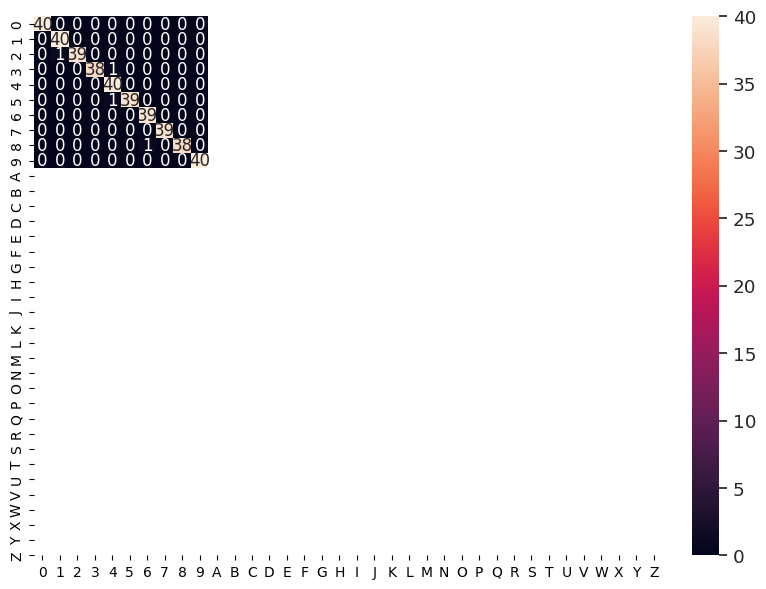

In [65]:
fig, ax = plt.subplots(figsize=(10,7))
sns.set(font_scale=1.2)
ax = sns.heatmap(cm,
                annot=True,
                fmt='g',
                xticklabels=all_characters,
                yticklabels=all_characters,
                annot_kws={"size": 12}
                )
plt.show()

---

## 🎙️ Gradio Web Interface

Interactive web interface for testing the trained model with real audio recordings or uploaded files.

In [66]:
import sys
import os
best_model_path = "model/CNN-Best.pkl"
# Add inference module to path
inference_path = os.path.join(os.getcwd(), 'inference')
if inference_path not in sys.path:
    sys.path.insert(0, inference_path)

from app_gradio import create_gradio_interface

# Create the Gradio interface with the best model
interface = create_gradio_interface(model_path=best_model_path)

print("✅ Gradio interface created successfully!")
print(f"   Model: {best_model_path}")

/root/minor/keyboard_sound/myenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Loading model from: model/CNN-Best.pkl
Device: CUDA
⚠ Warning: Unknown model type, defaulting to CNN
First 5 keys: ['conv1.conv.0.weight', 'conv1.conv.0.bias', 'conv1.conv.1.weight', 'conv1.conv.1.bias', 'conv1.conv.1.running_mean']
Creating CNN model with 36 classes...
Using alphanumeric labels (0-9, a-z)
Model parameters: 4,856,932
Model test successful - output shape: torch.Size([1, 36])
✓ Model loaded successfully!

✅ Gradio interface created successfully!
   Model: model/CNN-Best.pkl


In [67]:
# Launch the Gradio interface
# Options:
#   share=True  : Create a public shareable link (requires internet)
#   share=False : Local access only (default)
#   server_port=7860 : Specify a custom port

print("\n🚀 Launching Gradio web interface...")
print("   Once launched, the interface will be available at the URL shown below.")
print("   Use it to test the model with real-time audio recording or file uploads.\n")

# Launch with auto-reload disabled in notebook environment
interface.launch(
    share=True,
    inline=False,  # Display inline in Jupyter notebook
    quiet=True,   # Suppress Gradio logs for cleaner output
)


🚀 Launching Gradio web interface...
   Once launched, the interface will be available at the URL shown below.
   Use it to test the model with real-time audio recording or file uploads.

* Running on public URL: https://02135a970fd078b01f.gradio.live
